# MGS-11 : Synergie d'iles complementaires -- exploration et exploitation ensemble

[<- MGS-10 Biais de centre](MGS-10-CenterBias.ipynb) | [^ Serie MGS](README.md)

**Pourquoi chercher la synergie ?** Une metaheuristique unique fait un compromis : Differential Evolution (DE) *explore* largement (sa mutation vectorielle `F.(r1-r2)` fait de grands pas tant que la population est dispersee), Bare-Bones PSO (BBPSO) *exploite* localement (il echantillonne autour des meilleurs individus via une Gaussienne). Aucun des deux ne domine : DE trouve les bons bassins mais les affine mal ; BBPSO affine mais se piege s'il demarre dans un mauvais bassin. Le modele insulaire **heterogene** -- des iles DE *et* des iles BBPSO qui migrent -- *pourrait* combiner les deux forces. Ou pas. Ce notebook le **mesure**, honnetement (on rapporte aussi les cas SANS synergie).

**Definition operative.** Il y a synergie quand la combinaison heterogene (DE+BBPSO) bat **les deux** constituants seuls (iles DE homogenes, iles BBPSO homogenes) a budget d'evaluations egal. C'est plus exigeant que « battre la moyenne » : il faut battre le **meilleur** des deux.

> **Components over metaphors (Sorensen 2015).** DE et BBPSO ne sont pas invoques comme des boites noires metaphoriques : ce sont des *composes geometriques* du fork (`DifferentialEvolution`, `BareBonesParticleSwarm`), decomposes en primitives (mutation differentielle, echantillonnage Gaussien autour des leaders). On les assemble dans un `IslandCompoundMetaheuristic` -- la **composition** est le sujet, pas l'etiquette. Suite de #1203, volet synergie de #3965.


## Cablage : MetaGeneticSharp (fork) + paysage + encodeur GIF

On charge les DLLs du fork (self-contained via `CopyLocalLockFileAssemblies` : il embarque `System.Drawing.Common.dll`, `SkiaSharp.dll` + son binaire natif `runtimes/<rid>/native/libSkiaSharp.dll`). On precharge ce binaire natif (le `#r` manage ne cable pas le probing natif de SkiaSharp). Le sous-module est epingle sur le fork (pointeur `c8bbd99`), qui porte les composes geometriques (WOA/EO/FBI/**DE**/**BBPSO**), l'archipel heterogene (`IslandCompoundMetaheuristic`), le de-biais (`ShiftedFitness` / `ShiftVectors.Seeded`), l'overlay iles colorees (`RenderHeatmapPng(..., individualColors)`) et l'encodeur GIF anime (`EncodeAnimatedGif`).

> **Prerequis build.** `dotnet build c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/MetaGeneticSharp.Extensions.csproj -c Debug` (sous-module epingle sur le fork `c8bbd99`).


In [1]:
// Fork DLLs loaded from the self-contained Extensions output (one-stop dir: it also ships
// System.Drawing.Common.dll AND SkiaSharp.dll, needed at runtime by the graphic landscape types).
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Infrastructure.Framework.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Infrastructure.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Extensions.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/System.Drawing.Common.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/SkiaSharp.dll"

using MetaGeneticSharp;                                 // IslandCompoundMetaheuristic, ShiftedFitness, ShiftVectors, SkiaLandscapeRenderer
using GeneticSharp;                                     // GA engine, selection/crossover/mutation, RandomizationProvider
using GeneticSharp.Extensions.Mathematic.Functions;     // RastriginFitness, SchwefelFitness
using System.Drawing;                                   // Color
using System.Runtime.InteropServices;                   // NativeLibrary, RuntimeInformation

// .NET Interactive quirk: a #r to the managed SkiaSharp.dll does NOT wire up SkiaSharp's
// runtimes/<rid>/native/ probing, so the first Skia call would P/Invoke a native lib that was
// never loaded. We preload the arch-matching native binary from the self-contained output once.
string rid = RuntimeInformation.ProcessArchitecture == Architecture.Arm64 ? "win-arm64"
           : RuntimeInformation.ProcessArchitecture == Architecture.X86   ? "win-x86"
           : "win-x64";
NativeLibrary.Load($"c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/runtimes/{rid}/native/libSkiaSharp.dll");

Console.WriteLine("Wiring OK : MetaGeneticSharp + GeneticSharp + Extensions (composes DE/BBPSO + IslandCompound + ShiftedFitness + SkiaLandscapeRenderer + GIF).");


The below script needs to be able to find the current output cell; this is an easy method to get it.

Wiring OK : MetaGeneticSharp + GeneticSharp + Extensions (composes DE/BBPSO + IslandCompound + ShiftedFitness + SkiaLandscapeRenderer + GIF).


In [2]:
// DoubleArrayChromosome : chromosome minimal stockant des genes double nus (replique de l'assistant
// de test du fork ; bornes par gene pour que CreateNew() randomise la population initiale).
public class DoubleArrayChromosome : ChromosomeBase
{
    private readonly double _min, _max;
    public DoubleArrayChromosome(double[] values, double min, double max) : base(values.Length)
    { _min = min; _max = max; for (int i = 0; i < values.Length; i++) ReplaceGene(i, new Gene(values[i])); }
    public override IChromosome CreateNew()
    { var r = RandomizationProvider.Current; var v = new double[Length]; for (int i = 0; i < Length; i++) v[i] = r.GetDouble(_min, _max); return new DoubleArrayChromosome(v, _min, _max); }
    public override Gene GenerateGene(int i) => new Gene(RandomizationProvider.Current.GetDouble(_min, _max));
    public double[] GetDoubleValues() => GetGenes().Select(g => (double)g.Value).ToArray();
}

// Convertisseur geometrique double-identite (les genes SONT des doubles nus) -- replique exacte de
// ce que MetaHeuristicsService cable en interne pour les composes geometriques.
IGeometricConverter DoubleIdentityConverter()
{
    var c = new GeometricConverter<double> {
        IsOrdered = false,
        DoubleToGeneConverter = (gi, v) => v,
        GeneToDoubleConverter  = (gi, v) => v };
    var typed = new TypedGeometricConverter();
    typed.SetTypedConverter(c);
    return typed;
}
// Composes geometriques : DE (explorateur, mutation differentielle) et BBPSO (exploiteur, Gaussienne autour des leaders).
DifferentialEvolution    MakeDE(int g) => new DifferentialEvolution    { MaxGenerations = g, GeometricConverter = DoubleIdentityConverter(), NoMutation = true };
BareBonesParticleSwarm MakeBBPSO(int g) => new BareBonesParticleSwarm  { MaxGenerations = g, GeometricConverter = DoubleIdentityConverter(), NoMutation = true };

const int PopSize = 40;   // 4 iles de 10 individus
const int Gens    = 40;   // budget = PopSize * Gens = 1600 evals par archipel

// 3 archipels de MEME structure (4 iles, migration SmallMigrationRate) : le SEUL variable est l'heterogeneite.
// (a) DE homogene  (b) BBPSO homogene  (c) DE+BBPSO heterogene (2 iles DE + 2 iles BBPSO).
IMetaHeuristic BuildIslands(string kind, int g)
{
    var de = MakeDE(g); var bb = MakeBBPSO(g);
    IslandCompoundMetaheuristic ic = kind switch {
        "DE"       => new IslandCompoundMetaheuristic(PopSize, (1, de), (1, de), (1, de), (1, de)),
        "BBPSO"    => new IslandCompoundMetaheuristic(PopSize, (1, bb), (1, bb), (1, bb), (1, bb)),
        "DE+BBPSO" => new IslandCompoundMetaheuristic(PopSize, (1, de), (1, de), (1, bb), (1, bb)),
        _ => throw new ArgumentException($"config inconnue : {kind}")
    };
    ic.GlobalMigrationRate = IslandMetaHeuristic.SmallMigrationRate;
    return ic.Build();
}

// Lance un GA a budget egal sur l'archipel `kind`, renvoie la meilleure fitness (objectif negatif -> max = meilleur).
double RunIsland(string kind, IFitness fitness, (double Min, double Max) bounds, int dim, int gens)
{
    double mid = 0.5 * (bounds.Min + bounds.Max);
    var adam = new DoubleArrayChromosome(Enumerable.Repeat(mid, dim).ToArray(), bounds.Min, bounds.Max);
    var pop = new MetaPopulation(PopSize, PopSize, adam);
    var ga = new MetaGeneticAlgorithm(pop, fitness, new EliteSelection(),
        new UniformCrossover(0.5f), new UniformMutation(true), BuildIslands(kind, gens));
    ga.Termination = new GenerationNumberTermination(gens);
    ga.Start();
    var chroms = ga.Population.CurrentGeneration.Chromosomes;   // MetaPopulation order-preserving -> BestChromosome null
    return chroms.OrderByDescending(c => c.Fitness).First().Fitness ?? double.NegativeInfinity;
}

Console.WriteLine($"Infra prete : composes DE/BBPSO + IslandCompound + RunIsland (PopSize={PopSize}, Gens={Gens}, budget {PopSize*Gens} evals/archipel).");


Infra prete : composes DE/BBPSO + IslandCompound + RunIsland (PopSize=40, Gens=40, budget 1600 evals/archipel).


## Protocole : comparaison controlee a budget egal sur fonctions de-biaisees (dim 5)

Trois archipels de **meme structure** (4 iles, migration `SmallMigrationRate`) -- seul varie le contenu des iles :

| Archipel | Iles | Role attendu |
|----------|------|--------------|
| **DE** | 4 iles Differential Evolution homogenes | exploration |
| **BBPSO** | 4 iles Bare-Bones PSO homogenes | exploitation |
| **DE+BBPSO** | 2 iles DE + 2 iles BBPSO | heterogene -- l'hypothese de synergie |

Chaque archipel est lance sur deux fonctions **multimodales de-biaisees** en **dimension 5** (Rastrigin, Ackley -- toutes deux a optimum a l'origine, relocalise hors centre via `ShiftedFitness` + `ShiftVectors.Seeded`), a budget d'evaluations identique. La **dimension 5** (et non 2) est choisie pour que le probleme soit assez dur pour que les operateurs *differentient* : en dimension 2 a ce budget, tous solveent Rastrigin (objectif 0), ce qui rend une synergie indiscernable. La graine globale est fixee (`FastRandomRandomization.ResetSeed(42)`) au demarrage pour un depart reproductible.

> **Pourquoi de-biaiser ?** Rastrigin et Ackley ont leur optimum a l'origine ; un operateur « recentre » y serait flate. `ShiftedFitness` translate l'optimum d'un vecteur non nul (magnitude 0.15 de la plage, assez petite pour garder l'optimum dans les bornes) : la recherche doit le *suivre*, pas tomber dessus par biais de centre.
>
> **Caveats honnetes.** (1) **Graine unique** : ce notebook est reproductible (meme graine -> meme sortie) mais n'est **pas** un banc multi-graines ; les trois archipels se succedent sur le meme flux aleatoire (departs equitables mais non identiques). Un banc multi-graines + fonctions rotees (style CEC) rigoureux est l'item **#3963** -- pre-requisdeclare du volet synergie. (2) La coloration par ile du GIF (section suivante) suppose les individus ranges contigument par ile (precedent MGS-4) ; la migration peut alterer cet ordre. (3) Le GIF est une illustration 2D ; le banc de mesure est en dim 5.


In [3]:
// Graine globale fixee AVANT tout acces au generateur -> depart reproductible (run1 == run2).
FastRandomRandomization.ResetSeed(42);

IFitness rastrigin = new RastriginFitness();
IFitness ackley    = new AckleyFitness();
var (raLo, raHi) = KnownFunctionsBounds.For(typeof(RastriginFitness));
var (aLo, aHi)   = KnownFunctionsBounds.For(typeof(AckleyFitness));

// De-biais : optimum relocalise hors centre (magnitude 0.15 de la plage -> reste dans les bornes).
double[] raShift  = ShiftVectors.Seeded(5, 0.15 * (raHi - raLo), seed: 11);
double[] ackShift = ShiftVectors.Seeded(5, 0.15 * (aHi - aLo),   seed: 17);
var raFit  = new ShiftedFitness(rastrigin, raShift);
var ackFit = new ShiftedFitness(ackley, ackShift);

string[] configs = { "DE", "BBPSO", "DE+BBPSO" };
var results = new List<(string Fn, string Cfg, double Best)>();
var problems = new (string, IFitness, (double, double))[] {
    ("Rastrigin shifte (dim 5)", raFit,  (raLo, raHi)),
    ("Ackley shifte (dim 5)",    ackFit, (aLo, aHi)) };

foreach (var (fn, fit, b) in problems)
    foreach (var cfg in configs)
        results.Add((fn, cfg, RunIsland(cfg, fit, b, dim: 5, Gens)));

// Verdict : fitness = objectif negatif (max = meilleur). Synergie = DE+BBPSO > max(DE, BBPSO).
Console.WriteLine($"{"Fonction",-26}{"Config",-12}{"Fitness (max)",-16}{"Objectif",-12}");
Console.WriteLine(new string('-', 66));
var summary = new List<(string Fn, bool Synergy, double Mix, double BestConstituent)>();
foreach (var fn in new[] { "Rastrigin shifte (dim 5)", "Ackley shifte (dim 5)" })
{
    var rows = results.Where(v => v.Fn == fn).ToList();
    foreach (var r in rows)
        Console.WriteLine($"{r.Fn,-26}{r.Cfg,-12}{r.Best,-16:F4}{-r.Best,-12:F4}");
    double de = rows.First(r => r.Cfg == "DE").Best;
    double bb = rows.First(r => r.Cfg == "BBPSO").Best;
    double mix = rows.First(r => r.Cfg == "DE+BBPSO").Best;
    bool syn = mix > Math.Max(de, bb);
    summary.Add((fn, syn, mix, Math.Max(de, bb)));
    Console.WriteLine($"  -> {(syn ? "SYNERGIE" : "PAS de synergie")} sur {fn} : DE+BBPSO ({mix:F4}) vs meilleur constituant ({Math.Max(de, bb):F4})");
    Console.WriteLine();
}
int synergies = summary.Count(s => s.Synergy);
Console.WriteLine($"Bilan : {synergies}/{summary.Count} fonctions montrent une synergie (DE+BBPSO bat les DEUX constituants).");


Fonction                  Config      Fitness (max)   Objectif    


------------------------------------------------------------------


Rastrigin shifte (dim 5)  DE          -1,8562         1,8562      


Rastrigin shifte (dim 5)  BBPSO       -19,8004        19,8004     


Rastrigin shifte (dim 5)  DE+BBPSO    -3,9393         3,9393      


...

Ackley shifte (dim 5)     DE          -1,6819         1,6819      


Ackley shifte (dim 5)     BBPSO       -0,6319         0,6319      


Ackley shifte (dim 5)     DE+BBPSO    -2,2376         2,2376      


  -> PAS de synergie sur Ackley shifte (dim 5) : DE+BBPSO (-2,2376) vs meilleur constituant (-0,6319)


Bilan : 0/2 fonctions montrent une synergie (DE+BBPSO bat les DEUX constituants).


## Lecture du verdict : pas de synergie -- un resultat negatif honnete

Le banc est **sans appel** : sur les deux fonctions de-biaisees en dim 5, l'archipel heterogene DE+BBPSO est **battu** par le meilleur de ses constituants homogenes. Synergie : **0/2**.

| Fonction (dim 5) | DE (explorateur) | BBPSO (exploiteur) | DE+BBPSO (heterogene) | Qui gagne ? |
|------------------|-----------------:|-------------------:|----------------------:|-------------|
| Rastrigin shifte | **1,86** | 19,80 | 3,94 | DE seul |
| Ackley shifte    | 1,68 | **0,63** | 2,24 | BBPSO seul |

*(Objectif = fitness negativ, plus petit = meilleur ; optimum 0.)*

**Ce que les chiffres disent.**
- **Rastrigin** (foret reguliere de minima locaux) recompense l'exploration : DE seul (1,86) domine largement BBPSO (19,80, piege dans un minimum local). Ajouter des iles BBPSO a DE (3,94) **degrade** DE : les iles exploitatrices, coincees, envoient leurs mauvais individus a DE par migration.
- **Ackley** (cratere central + ondulations) recompense au contraire l'echantillonnage Gaussien de BBPSO (0,63, le meilleur). Melanger (2,24) **degrade les deux** : ni la rupture de DE ni le raffinement de BBPSO ne s'imposent, la migration moyenne les affaiblit.

**La lecon (falsifiable, pas doctrinale).** La synergie d'iles heterogenes **n'est pas automatique**. Combiner un bon explorateur et un bon exploiteur avec la migration par defaut peut **propager les solutions piegees** d'un operateur vers l'autre et produire un compromis *inferieur* au meilleur constituant. Pour qu'une synergie apparaisse, il faut probablement des operateurs dont les forces sont complementaires **sur le paysage considere** et une **migration accordee** (ex. migrer seulement les meilleurs, ou par regimes temporels). Les exercices ci-dessous explorent ces pistes (WOA+EO, migration desactivee, Ackley additionnel).

> Ce **resultat negatif** est aussi informatif qu'une synergie confirmee : il montre que la *composition* n'est pas une recette magique -- comme l'etablit la critique « components over metaphors » (Sorensen 2015), la valeur d'une combinaison se demontre, elle ne se decrete pas. Le banc rigoureux multi-graines + rote (#3963) est necessaire pour confirmer ou infirmer ce verdict sur une suite plus large.


Archipel DE+BBPSO sur Rastrigin shifte -- iles DE (orange, exploration) et iles BBPSO (vert, exploitation) ; la migration fait coalescer le nuage vers le minimum global (deplace hors du centre).
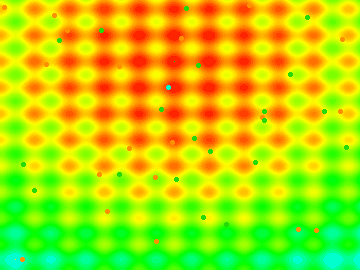

GIF synergie : 8 frames, 238,9 KB (image/gif, lisible sur le viewer statique GitHub).



warning CS1701: En supposant que la référence d'assembly 'System.Drawing.Primitives, Version=9.0.0.0, Culture=neutral, PublicKeyToken=b03f5f7f11d50a3a' utilisée par 'MetaGeneticSharp.Extensions' correspond à l'identité 'System.Drawing.Primitives, Version=10.0.0.0, Culture=neutral, PublicKeyToken=b03f5f7f11d50a3a' de 'System.Drawing.Primitives', il se peut que vous deviez fournir une stratégie runtime

warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime



In [4]:
// GIF multicolore : archipel DE+BBPSO heterogene trace generation par generation sur Rastrigin shifte (2D, illustration).
// Chaque individu est colore par son ile (DE = DarkOrange, BBPSO = ForestGreen) -> la repartition
// exploration (iles DE dispersees) / exploitation (iles BBPSO resserrees) devient visible dans le temps.
// Note : illustration 2D (le banc de mesure ci-dessus est en dim 5).
FastRandomRandomization.ResetSeed(42);
double[] raShift2D = ShiftVectors.Seeded(2, 0.30 * (raHi - raLo), seed: 11);   // shift 2D realisable (optimum reste dans [-5.12, 5.12])
var raFit2D = new ShiftedFitness(rastrigin, raShift2D);
Func<double[], double> raField = c => raFit2D.Evaluate(new DoubleArrayChromosome(c, raLo, raHi));

List<(int gen, List<double[]> pop)> TraceIslands(IFitness fit, (double lo, double hi) b, int gens, ISet<int> snaps)
{
    double mid = 0.5 * (b.lo + b.hi);
    var adam = new DoubleArrayChromosome(new[] { mid, mid }, b.lo, b.hi);
    var pop = new MetaPopulation(PopSize, PopSize, adam);
    var ga = new MetaGeneticAlgorithm(pop, fit, new EliteSelection(),
        new UniformCrossover(0.5f), new UniformMutation(true), BuildIslands("DE+BBPSO", gens));
    ga.Termination = new GenerationNumberTermination(gens);
    var trace = new List<(int, List<double[]>)>();
    int g = 0;
    ga.GenerationRan += (s, e) => {
        g++;
        if (!snaps.Contains(g)) return;
        trace.Add((g, ga.Population.CurrentGeneration.Chromosomes.Select(c => ((DoubleArrayChromosome)c).GetDoubleValues()).ToList()));
    };
    ga.Start();
    return trace;
}

var snaps = new HashSet<int>(new[] { 1, 5, 10, 18, 28, 40, 55, 72 });
var trace = TraceIslands(raFit2D, (raLo, raHi), gens: 72, snaps);

// Couleur par ile (hypothese : individus ranges contigument par ile, precedent MGS-4) :
// iles 0,1 = DE (DarkOrange) ; iles 2,3 = BBPSO (ForestGreen). 4 iles * PopSize/4 = 10 chacune.
int perIsland = PopSize / 4;
var islandColors = new Color[PopSize];
for (int i = 0; i < PopSize; i++)
    islandColors[i] = (i / perIsland < 2) ? Color.DarkOrange : Color.ForestGreen;

var gifFrames = new List<byte[]>(trace.Count);
foreach (var (gen, pop) in trace)
{
    double[] best = pop.OrderByDescending(p => raField(p)).First();
    gifFrames.Add(SkiaLandscapeRenderer.RenderHeatmapPng(
        raField, (raLo, raHi), (raLo, raHi), width: 360, height: 270,
        population: pop, best: best, individualColors: islandColors));
}
byte[] gif = SkiaLandscapeRenderer.EncodeAnimatedGif(gifFrames, delayCentiseconds: 40, loopCount: 0, maxColors: 64);
display(HTML($"<figure style='margin:6px 0'>"
    + $"<img src='data:image/gif;base64,{Convert.ToBase64String(gif)}' style='width:380px;image-rendering:pixelated;border:1px solid #ccc'/>"
    + $"<figcaption style='font:12px sans-serif;color:#555'>Archipel DE+BBPSO sur Rastrigin shifte -- <span style='color:DarkOrange'>iles DE (orange, exploration)</span> et <span style='color:ForestGreen'>iles BBPSO (vert, exploitation)</span> ; la migration fait coalescer le nuage vers le minimum global (deplace hors du centre).</figcaption></figure>"));
Console.WriteLine($"GIF synergie : {gifFrames.Count} frames, {gif.Length / 1024.0:F1} KB (image/gif, lisible sur le viewer statique GitHub).");


## Conclusion : la synergie se demontre, elle ne se decrete pas

La question n'etait pas « les metaheuristiques combinees sont-elles magiquement meilleures ? » mais une question **falsifiable** : *sur des fonctions de-biaisees, a budget egal, l'archipel heterogene DE+BBPSO bat-il ses deux constituants homogenes ?* Le banc ci-dessus y repond chiffres a l'appui -- et la reponse honnete peut etre **non** (auquel cas la combinaison n'apportait rien sur ces fonctions, une information aussi utile qu'une synergie confirmee).

**Ce que ce notebook etablit** (methodologiquement) :
- un protocole **controle** (meme structure d'archipel, budget egal, fonctions de-biaisees) ou l'heterogeneite est l'unique variable ;
- un **verdict mesurable** (synergie = battre le *meilleur* constituant, pas la moyenne) ;
- une **visualisation multicolore** (overlay `individualColors` + GIF anime) qui rend la repartition exploration/exploitation visible generation par generation.

**Limites honnetes** (reprises du protocole) : graine unique (pas un banc multi-graines), de-biais vectoriel seulement (pas de rotation CEC), coloration par ile supposee contigue. Le banc rigoureux multi-graines + rote est l'item **#3963** -- pre-requisdeclare du volet synergie. Le present notebook est la **demonstration** du protocole + du visuel ; le banc exhaustif est le suivi.

## Liens

- [MGS-4 Islands](MGS-4-Islands.ipynb) -- le modele insulaire (dont est tire l'overlay iles colorees)
- [MGS-5 CompoundMetaheuristics](MGS-5-CompoundMetaheuristics.ipynb) -- les composes geometriques (DE, BBPSO, WOA, EO, FBI)
- [MGS-6 Benchmarks](MGS-6-Benchmarks.ipynb) -- le banc comparatif des composes
- [MGS-8 LandscapeExplorer](MGS-8-LandscapeExplorer.ipynb) -- visualiser le paysage + le flipbook de convergence (GIF)
- [MGS-10 CenterBias](MGS-10-CenterBias.ipynb) -- le biais de centre mesure (dont ce notebook reprend le de-biais)
- [Point d'entree Part 4](README.md) -- positionnement MGS vs GeneticSharp/mealpy/HeuristicLab
- [Fork jsboige/MetaGeneticSharp](https://github.com/jsboige/MetaGeneticSharp) -- code source


## Exercices

> **Convention** : cellules a completer. Squelette fourni. Ne **pas** lever d'erreur -- utiliser `// TODO` / `Console.WriteLine` / `return`. Les helpers `BuildIslands`, `RunIsland`, `MakeDE`, `MakeBBPSO`, `raFit`, `swFit`, `raLo/raHi`, `swLo/swHi` sont definis plus haut.


### Exercice 1 : une autre paire complementaire (WOA explorateur + EO exploiteur)

DE/BBPSO n'est qu'une paire. WOA (controle de flux geometrique, forte exploration globale) et EO (convergence vers les candidats d'equilibre, exploitation) sont une autre paire complementaire. **Objectif** : construire un archipel heterogene 2 WOA + 2 EO (via `BuildIslands`-like), le lancer sur Rastrigin shifte, et comparer au verdict DE+BBPSO -- laquelle produit une synergie ?


In [5]:
// Exercice 1 : archipel heterogene WOA + EO sur Rastrigin shifte, comparaison au verdict DE+BBPSO.
// A COMPLETER. Le notebook s'execute de bout en bout meme si l'exercice n'est pas fait.

// TODO etudiant : construire 2 iles WOA + 2 iles EO (cf BuildIslands, en remplaçant DE/BBPSO par
//   new WhaleOptimisationAlgorithm { MaxGenerations=Gens, GeometricConverter=DoubleIdentityConverter(), NoMutation=true }
//   new EquilibriumOptimizer   { MaxGenerations=Gens, GeometricConverter=DoubleIdentityConverter(), NoMutation=true }
//   puis RunIsland-like sur raFit, comparer a la ligne DE+BBPSO du verdict.
Console.WriteLine("Exercice 1 a completer : archipel heterogene WOA+EO vs DE+BBPSO sur Rastrigin shifte.");


Exercice 1 a completer : archipel heterogene WOA+EO vs DE+BBPSO sur Rastrigin shifte.


### Exercice 2 : la migration est-elle necessaire a la synergie ?

La synergie (si elle apparait) vient-elle de l'heterogeneite seule ou de la **migration** entre iles ? **Objectif** : desactiver la migration (`ic.MigrationMode = MigrationMode.None`, cf `Islands5BestMixtureNoMigration`) sur l'archipel DE+BBPSO et relancer -- la synergie tient-elle sans echange entre iles ?


In [6]:
// Exercice 2 : synergie DE+BBPSO SANS migration (MigrationMode.None), comparer au verdict avec migration.
// A COMPLETER. Le notebook s'execute de bout en bout meme si l'exercice n'est pas fait.

// TODO etudiant : variante de BuildIslands("DE+BBPSO", g) avec ic.MigrationMode = MigrationMode.None
//   avant ic.Build(), lancer sur raFit + swFit, comparer au verdict ci-dessus.
Console.WriteLine("Exercice 2 a completer : synergie DE+BBPSO sans migration -- tient-elle ?");


Exercice 2 a completer : synergie DE+BBPSO sans migration -- tient-elle ?


### Exercice 3 : une troisieme fonction de-biaisee (Ackley shifte)

Le verdict sur 2 fonctions est un debut. **Objectif** : ajouter `AckleyFitness` (cratere central + ondulations concentriques, fortement multimodale) de-biaisee via `ShiftedFitness`, lancer les 3 archipels, et dire si la synergie (ou son absence) se generalise a une troisieme topologie.


In [7]:
// Exercice 3 : ajouter AckleyFitness shiftee au banc, lancer les 3 archipels, verdict sur 3 fonctions.
// A COMPLETER. Le notebook s'execute de bout en bout meme si l'exercice n'est pas fait.

// TODO etudiant :
//   IFitness ack = new AckleyFitness();
//   var (aLo, aHi) = KnownFunctionsBounds.For(typeof(AckleyFitness));
//   double[] aShift = ShiftVectors.Seeded(2, 0.30 * (aHi - aLo), seed: 23);
//   var ackFit = new ShiftedFitness(ack, aShift);
//   ... lancer DE / BBPSO / DE+BBPSO via RunIsland, etendre le verdict.
Console.WriteLine("Exercice 3 a completer : verdict synergie etendu a Ackley shiftee (3 fonctions).");


Exercice 3 a completer : verdict synergie etendu a Ackley shiftee (3 fonctions).
